In [2]:
# Importing Libraries
import seaborn as sns
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [32]:
df_DS_USA = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()
df_DS_USA['job_posted_month'] = df_DS_USA['job_posted_date'].dt.month
df_DS_USA_explode = df_DS_USA.explode('job_skills').dropna(subset=['job_skills'])


In [33]:
df_DS_USA_pivot = df_DS_USA_explode.pivot_table(
    index='job_posted_month',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
)

df_DS_USA_pivot.loc['Total']= df_DS_USA_pivot.sum()
df_DS_USA_pivot= df_DS_USA_pivot[df_DS_USA_pivot.loc['Total'].sort_values(ascending= False).index]
df_DS_USA_pivot=df_DS_USA_pivot.drop('Total')

df_DS_USA_pivot

job_skills,python,sql,r,sas,tableau,aws,spark,java,tensorflow,azure,...,asp.net core,clickup,couchdb,fedora,ocaml,mattermost,nuix,shogun,symfony,wrike
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,5243,3770,3362,1700,1630,1364,1356,916,896,817,...,1,1,1,0,0,0,1,0,1,0
2,3718,2670,2334,1144,1268,854,895,645,565,573,...,0,0,0,0,0,0,0,0,0,0
3,3394,2426,2189,1144,1126,848,787,575,529,538,...,0,0,0,0,0,0,0,1,0,0
4,3622,2463,2181,1204,1213,882,823,622,582,538,...,0,0,0,0,0,0,0,0,0,0
5,3232,2293,2016,1150,1174,797,774,629,517,521,...,0,0,0,0,0,0,0,0,0,0
6,3431,2442,2107,1158,1135,818,822,586,537,568,...,0,0,0,0,0,0,0,0,0,1
7,3541,2479,2210,1106,1223,860,802,581,570,607,...,0,0,0,1,0,0,0,0,0,0
8,4566,3324,2896,1598,1520,1076,1075,767,809,727,...,0,0,0,0,0,0,0,0,0,0
9,3112,2155,1791,1158,921,697,740,534,567,558,...,0,0,0,0,0,0,0,0,0,0


In [34]:
df_DS_USA_total=df_DS_USA.groupby('job_posted_month').size()

In [46]:
df_DS_USA_percent = df_DS_USA_pivot.div(df_DS_USA_total / 100, axis=0)
df_DS_USA_percent = df_DS_USA_percent.reset_index()
df_DS_USA_percent['job_post_month'] = df_DS_USA_percent['job_posted_month'].apply(
    lambda x: pd.to_datetime(f'2024-{x:02d}-01').strftime('%b')
)
df_DS_USA_percent = df_DS_USA_percent.set_index('job_post_month')
df_DS_USA_percent = df_DS_USA_percent.drop(columns='job_posted_month')
df_plot=  df_DS_USA_percent.iloc[:, :8]

df_plot

job_skills,python,sql,r,sas,tableau,aws,spark,java
job_post_month,,,,,,,,
Jan,75.820680,54.519161,48.618944,24.584237,23.571945,19.725235,19.609544,13.246565
Feb,75.020178,53.874092,47.094431,23.083132,25.585149,17.231638,18.058918,13.014528
Mar,71.019042,50.763758,45.804562,23.938062,23.561415,17.744298,16.467880,12.031806
Apr,74.419560,50.606123,44.811999,24.738032,24.922950,18.122046,16.909801,12.779947
May,73.840530,52.387480,46.058944,26.273703,26.822024,18.208819,17.683345,14.370573
Jun,73.864370,52.572659,45.360603,24.930032,24.434876,17.610334,17.696448,12.615716
Jul,72.621001,50.840853,45.324036,22.682527,25.082034,17.637408,16.447908,11.915505
Aug,72.269706,52.611586,45.837290,25.292814,24.058246,17.030706,17.014878,12.139918
Sep,68.126095,47.176007,39.207531,25.350263,20.161996,15.258319,16.199650,11.690018


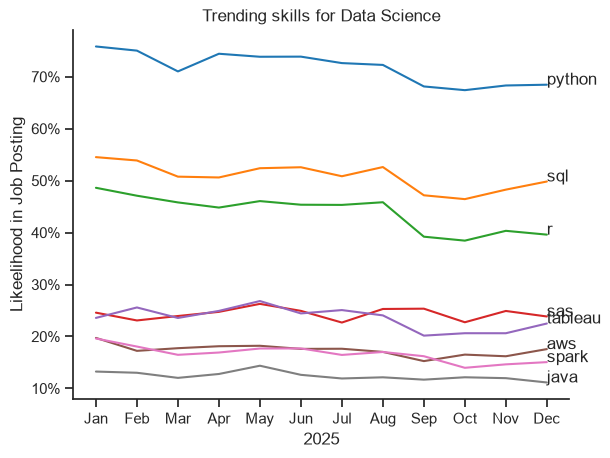

In [ ]:
sns.lineplot(data=df_plot, dashes=False, palette='tab10', legend=False)
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending skills for Data Science')
plt.xlabel('2025')
plt.ylabel('Likeelihood in Job Posting')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

for i, skill in enumerate(df_plot.columns[:8]):
    plt.text(len(df_plot) - 1, df_plot.iloc[-1, i], skill)

plt.show()